<a href="https://colab.research.google.com/github/Sofiacesari/Estrategia-de-Retenci-n-en-E-commerce-Recomendaci-n-de-Productos-Similares/blob/main/Estrategia_de_Retenci_n_en_E_commerce_Recomendaci_n_de_Productos_Similares.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabajo práctico final obligatorio - Sofía Odette Cesari HYM


# Selección del dataset y objetivos

Los datos utilizados en este proyecto provienen del desafío público "H&M Personalized Fashion Recommendations" alojado en la plataforma Kaggle. El dataset original fue proporcionado por el Grupo H&M para fines de investigación y desarrollo de modelos de recomendación en la industria de la moda. Puede encontrase en: https://www.kaggle.com/competitions/h-and-m-personalized-fashion-recommendations/data

La elección de este dataset y la problemática asociada se basa en los siguientes puntos de interés:


- **Problemática de Negocio Real:** En el entorno del e-commerce, uno de los mayores puntos de fricción es el "Out of Stock". Cuando un cliente encuentra un producto agotado, la probabilidad de abandono del sitio es alta. Este proyecto busca resolver dicha problemática mediante un sistema de recomendación técnica.


- **Valor Estratégico:** El desarrollo de un buscador de productos similares permite retener al usuario ofreciéndole alternativas que compartan características idénticas (mismo tipo de prenda, mismo color y misma estampa). Esto impacta directamente en la conversión de ventas y en la satisfacción del cliente.

# Carga de datos

In [ ]:
# Importación de librerias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/articles.csv')

In [ ]:
df

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105537,953450001,953450,5pk regular Placement1,302,Socks,Socks & Tights,1010014,Placement print,9,Black,...,Socks Bin,F,Menswear,3,Menswear,26,Men Underwear,1021,Socks and Tights,Socks in a fine-knit cotton blend with a small...
105538,953763001,953763,SPORT Malaga tank,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey,A,Ladieswear,1,Ladieswear,2,H&M+,1005,Jersey Fancy,Loose-fitting sports vest top in ribbed fast-d...
105539,956217002,956217,Cartwheel dress,265,Dress,Garment Full body,1010016,Solid,9,Black,...,Jersey,A,Ladieswear,1,Ladieswear,18,Womens Trend,1005,Jersey Fancy,"Short, A-line dress in jersey with a round nec..."
105540,957375001,957375,CLAIRE HAIR CLAW,72,Hair clip,Accessories,1010016,Solid,9,Black,...,Small Accessories,D,Divided,2,Divided,52,Divided Accessories,1019,Accessories,Large plastic hair claw.


# Dicciónario de variables



    








| Variable | Tipo de Dato | Descripción |
| :--- | :--- | :--- |
| **article_id** | `int64` | Identificador único numérico del producto (10 dígitos). |
| **product_code** | `int64` | Identificador numérico del modelo base (diseño). |
| **prod_name** | `object` | Nombre comercial del producto. |
| **product_type_no** | `int64` | Código numérico del tipo de prenda. |
| **product_type_name** | `object` | Descripción de la categoría de prenda (ej: T-shirt). |
| **product_group_name** | `object` | Categoría macro del producto (ej: Garment Upper body). |
| **graphical_appearance_no** | `int64` | Código numérico de la estampa o textura. |
| **graphical_appearance_name** | `object` | Descripción de la estampa (ej: Solid, Floral). |
| **colour_group_code** | `int64` | Código numérico del grupo de color. |
| **perceived_colour_value_id** | `int64` | Identificador númerico para el color percibido del producto. |
| **perceived_colour_value_name** | `object` | Nombre del color percibido del producto. |
| **perceived_colour_master_id** | `int64` | Identificador númerico de la categoria generalizada del color percibido. |
| **perceived_colour_master_name** | `object` | Nombre de la categoria generalizada del color percibido. |
| **department_no** | `int64` | Identificador númerico del departamento al que corresponde el producto. |
| **department_name** | `object` | Nombre del departamento al que corresponde el producto. |
| **index_code** | `object` | Identificador alfabético de la categora a la que pertenece el producto.|
| **index_name** | `object` | Categoria a la que pertenece el producto.|
| **index_group_no** | `int64` | Identificador númerico de la categoria general a la cual pertenece el producto.|
| **index_group_name** | `object` | Categoria general a la cual pertenece el producto.|
| **section_name** | `object` | Sección de la tienda donde pertenece el producto.|
| **garment_group_no** | `int64` | Identificador númerico de la familia general de la prenda a la que pertenece el producto.|
| **garment_group_name** | `object` | Familia general de la prenda a la que pertenece el producto.|
| **detail_desc** | `object` | Descripción detallada de las caracteristicas del producto.|

# Limpieza de datos


In [ ]:
print(df.isna().sum())

print(df.duplicated().sum())

print(df.dtypes)

df['prod_name'].map(type).value_counts(normalize=True) * 100

article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
dtype: int64
0
article_id                       int64
product_code                     int64
prod_na

,proportion
prod_name,
<class 'str'>,100.0


Se realizó una auditoría técnica sobre el dataset para garantizar la integridad del modelo, obteniendo los siguientes resultados:

**Integridad de registros:** No se detectaron valores nulos (isna) en columnas críticas como article_id o product_type_no, permitiendo conservar la totalidad de la muestra.

**Unicidad:** El control de redundancia (duplicated) arrojó un valor de 0, confirmando que cada registro representa una variante de producto única.

**Consistencia técnica:** Se verificó mediante dtypes que las variables identificadoras y categóricas operen bajo el formato int64, asegurando la compatibilidad con el algoritmo.

**Normalización de nombres** La columna prod_name presenta un 100% de consistencia como tipo string, descartando errores de carga o tipos de datos mixtos.

Al no presentar valores nulos, duplicados ni inconsistencias de formato, se procedió a trabajar con la base de datos íntegra.

In [ ]:
def inspect_col(col):
  return (
      col.map(type)
      .value_counts()
      .rename("count")
      .to_frame()
      .assign(percent=lambda x: x / x.sum()*100)
  )

In [ ]:
import pandas as pd

results = []
for col_name in df.columns:
    inspection_df = inspect_col(df[col_name])
    inspection_df = inspection_df.reset_index()
    inspection_df.columns = ['type', 'count', 'percent']
    inspection_df['column_name'] = col_name
    results.append(inspection_df)

if results:
    combined_df = pd.concat(results).set_index(['column_name', 'type'])
    print("\nInspección consolidada de tipos de datos por columna:")
    display(combined_df)
else:
    print("No se encontraron columnas para inspeccionar.")


Inspección consolidada de tipos de datos por columna:


,,count,percent
column_name,type,,
article_id,<class 'int'>,105542,100.000000
product_code,<class 'int'>,105542,100.000000
prod_name,<class 'str'>,105542,100.000000
product_type_no,<class 'int'>,105542,100.000000
product_type_name,<class 'str'>,105542,100.000000
product_group_name,<class 'str'>,105542,100.000000
graphical_appearance_no,<class 'int'>,105542,100.000000
graphical_appearance_name,<class 'str'>,105542,100.000000
colour_group_code,<class 'int'>,105542,100.000000


Adicionalmente, se desarrolló e implementó una función personalizada de inspección de tipos a nivel de registro (inspect_col). Esta técnica permitió validar que columnas críticas como prod_name y detail_desc mantienen una consistencia absoluta en sus tipos de datos (100% strings), descartando la presencia de datos mixtos que pudieran afectar el procesamiento de lenguaje natural o la lógica del modelo de recomendación.

In [ ]:
df[df["detail_desc"].map(type) == float]

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
1467,351332007,351332,Marshall Lace up Top,252,Sweater,Garment Upper body,1010018,Treatment,7,Grey,...,Jersey Fancy DS,D,Divided,2,Divided,58,Divided Selected,1005,Jersey Fancy,NaN
2644,420049002,420049,OL TAGE PQ,87,Boots,Shoes,1010016,Solid,13,Beige,...,Premium Quality,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,NaN
2645,420049003,420049,OL TAGE PQ,87,Boots,Shoes,1010016,Solid,23,Dark Yellow,...,Premium Quality,C,Ladies Accessories,1,Ladieswear,64,Womens Shoes,1020,Shoes,NaN
2742,426199002,426199,Ellen Shortie Daisy Low 3p,286,Underwear bottom,Underwear,1010016,Solid,9,Black,...,Casual Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear",NaN
2743,426199010,426199,Ellen Shortie Daisy Low 3p,286,Underwear bottom,Underwear,1010017,Stripe,8,Dark Grey,...,Casual Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67838,752458001,752458,Poissy boho dress,265,Dress,Garment Full body,1010007,Embroidery,10,White,...,Dress,A,Ladieswear,1,Ladieswear,6,Womens Casual,1013,Dresses Ladies,NaN
72720,768842001,768842,Andrews set,270,Garment Set,Garment Full body,1010017,Stripe,10,White,...,Baby Boy Woven,G,Baby Sizes 50-98,4,Baby/Children,41,Baby Boy,1006,Woven/Jersey/Knitted mix Baby,NaN
72721,768842004,768842,Andrews set,270,Garment Set,Garment Full body,1010004,Check,73,Dark Blue,...,Baby Boy Woven,G,Baby Sizes 50-98,4,Baby/Children,41,Baby Boy,1006,Woven/Jersey/Knitted mix Baby,NaN
93144,856985001,856985,Pogo rope,67,Belt,Accessories,1010016,Solid,12,Light Beige,...,Belts,C,Ladies Accessories,1,Ladieswear,65,Womens Big accessories,1019,Accessories,NaN


In [ ]:
df["detail_desc"] = (
    df["detail_desc"]
    .astype("string")
    .fillna("non_defined")
)

inspect_col(df["detail_desc"])

,count,percent
detail_desc,,
<class 'str'>,105542,100.0


Se identificó que la variable detail_desc contenía registros con valores nulos, detectados mediante un mapeo de tipos (float). Dado que la descripción es una característica valiosa pero no indispensable para el cálculo de distancias numéricas, se optó por una estrategia de imputación. Se convirtieron los registros a tipo string y se completaron los valores faltantes con la etiqueta 'non_defined'. Esto permitió mantener la integridad del dataset original sin perder artículos valiosos para el sistema de recomendación.

# Exploración inicial

### **Análisis de Inventario y Rotación**
Al evaluar la arquitectura del catálogo, se observa una fuerte concentración en las macro-categorías “Garment Upper body” y “Garment Lower body”. Esta distribución permite identificar tres conclusiones estratégicas:

**Riesgo de quiebre de stock:** Al concentrar el mayor volumen y nivel de rotación, estas categorías presentan también el mayor riesgo de agotamiento de SKU.

**Escalabilidad del modelo:** Con más de 11.000 artículos solo en prendas superiores, la gestión manual de sustitutos resulta inviable. La automatización mediante un buscador de similares se vuelve clave para sostener la continuidad de la venta.

**Red de contención:** La densidad del inventario asegura que el sistema disponga de un amplio universo de alternativas estéticas ante la falta de stock de un producto específico.

In [ ]:
df['product_group_name'].value_counts()

,count
product_group_name,
Garment Upper body,42741
Garment Lower body,19812
Garment Full body,13292
Accessories,11158
Underwear,5490
Shoes,5283
Swimwear,3127
Socks & Tights,2442
Nightwear,1899


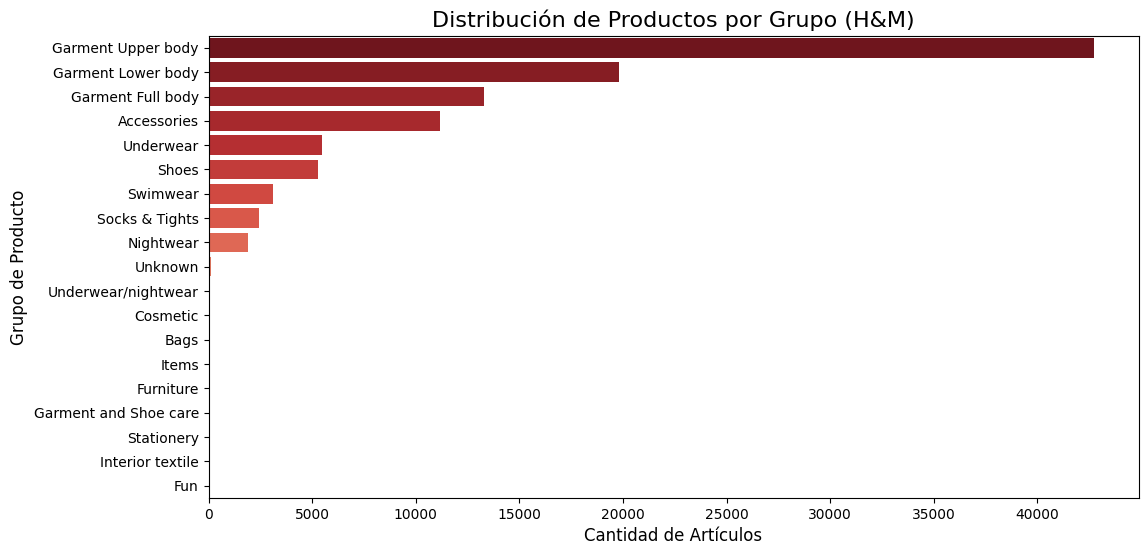

In [ ]:
conteo_grupos = df['product_group_name'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(
    x=conteo_grupos.values,
    y=conteo_grupos.index,
    hue=conteo_grupos.index,
    palette='Reds_r',
    legend=False
)

plt.title('Distribución de Productos por Grupo (H&M)', fontsize=16)
plt.xlabel('Cantidad de Artículos', fontsize=12)
plt.ylabel('Grupo de Producto', fontsize=12);


## Análisis de Segmentación y Conversión

La distribución del catálogo por divisiones comerciales revela una clara dominancia del segmento "Ladieswear", lo que define la prioridad estratégica del modelo:

**Impacto en ventas:** Al concentrar el mayor tráfico y volumen de transacciones, la recuperación de carritos por Out of Stock en esta categoría genera el mayor retorno de inversión directo.

**Reducción de fricción:** El buscador de similares actúa como una herramienta crítica para mitigar el abandono de compra en el público con mayor rotación del dataset.

**Especialización por nicho:** : La fragmentación del catálogo observada en el gráfico exige que el algoritmo opere con alta precisión dentro de cada segmento, garantizando que las alternativas respeten la intención de compra original del usuario.

**Segmentos de nicho (sport):** La menor densidad de artículos deportivos sugiere que el sistema deberá operar con mayor selectividad, activando con mayor frecuencia el umbral de tolerancia para evitar sugerencias forzadas entre categorías disímiles.



In [ ]:
df['index_group_name'].value_counts()

,count
index_group_name,
Ladieswear,39737
Baby/Children,34711
Divided,15149
Menswear,12553
Sport,3392


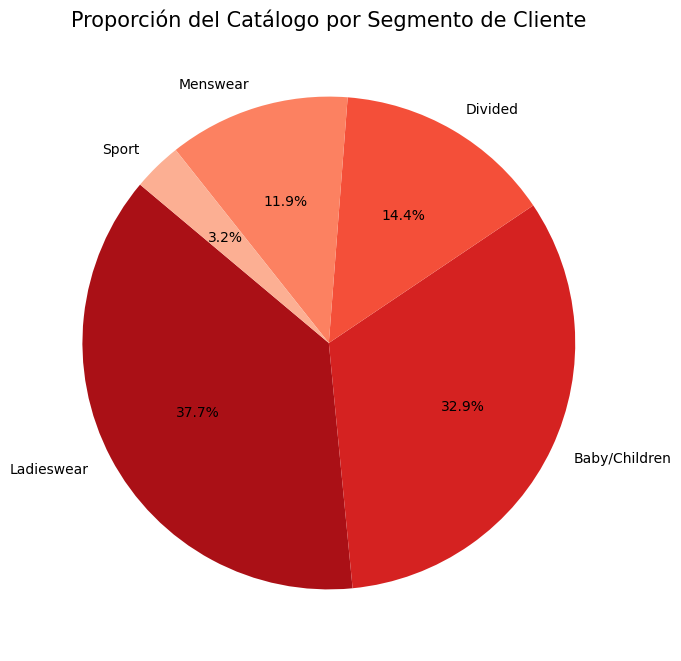

In [ ]:
conteo_index = df['index_group_name'].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(
    conteo_index.values,
    labels=conteo_index.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=sns.color_palette('Reds_r')
)
plt.title('Proporción del Catálogo por Segmento de Cliente', fontsize=15);

### Análisis de Jerarquía de Productos ###
En lugar de observar volúmenes totales, este análisis se centra en la diversidad estructural del catálogo de H&M. Se cuantificó la cantidad de "Tipos de Producto" únicos dentro de cada macro-categoría para entender la profundidad de cada departamento.

Estos resultados validan la decisión de utilizar product_type_no como la variable de identidad primaria. En un entorno tan diverso, la similitud matemática debe estar anclada a la morfología específica del objeto para garantizar que la recomendación sea un sustituto funcional real y no solo un artículo del mismo departamento.


In [ ]:
jerarquia = df.groupby(['product_group_name', 'product_type_name']).size().reset_index(name='cantidad')
print(jerarquia.sort_values(by='cantidad', ascending=False).head(10))

    product_group_name product_type_name  cantidad
58  Garment Lower body          Trousers     11169
49   Garment Full body             Dress     10362
69  Garment Upper body           Sweater      9302
70  Garment Upper body           T-shirt      7904
72  Garment Upper body               Top      4155
60  Garment Upper body            Blouse      3979
65  Garment Upper body            Jacket      3940
56  Garment Lower body            Shorts      3939
68  Garment Upper body             Shirt      3405
73  Garment Upper body          Vest top      2991


/tmp/ipykernel_186/3011878270.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


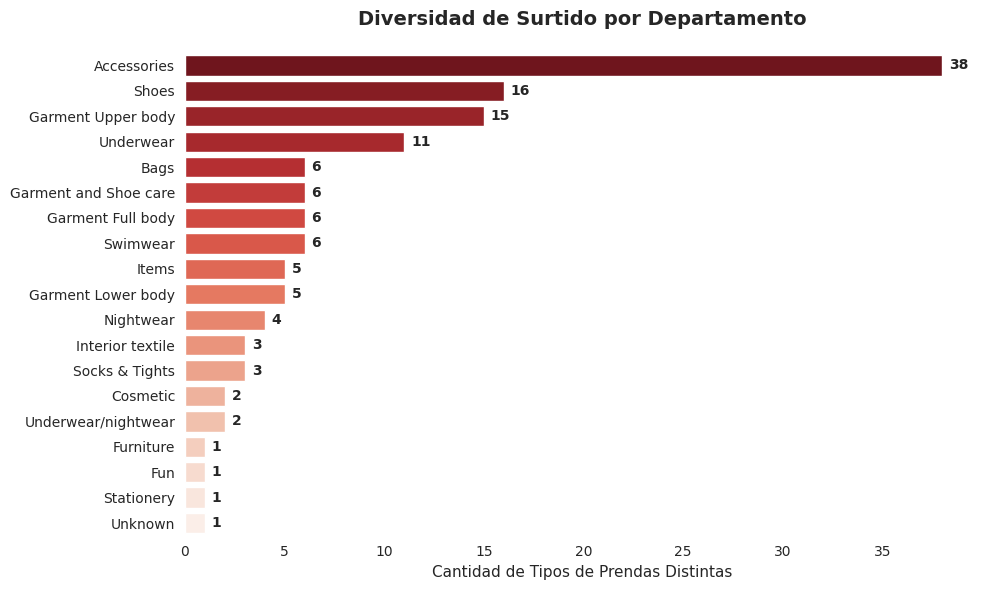

In [ ]:

capilaridad = df.groupby('product_group_name')['product_type_no'].nunique().sort_values(ascending=False).reset_index()
capilaridad.columns = ['Grupo de Producto', 'Tipos Únicos']


plt.figure(figsize=(10, 6))
sns.set_style("white")

ax = sns.barplot(
    data=capilaridad,
    x='Tipos Únicos',
    y='Grupo de Producto',
    palette='Reds_r'
)


sns.despine(left=True, bottom=True)

plt.title('Diversidad de Surtido por Departamento', fontsize=14, pad=20, fontweight='bold')
plt.xlabel('Cantidad de Tipos de Prendas Distintas', fontsize=11)
plt.ylabel('', fontsize=11)


for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                ha='left', va='center',
                xytext=(5, 0),
                textcoords='offset points',
                fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

## Análisis de Color y Variabilidad
La distribución de colores en el inventario justifica la configuración del modelo:

**Precisión de matices:** La diversidad de tonos fundamenta el uso de perceived_colour_value_id, evitando que el sistema recomiende colores incorrectos ante un quiebre de stock.

**Dominancia del negro:** Al ser el color con mayor volumen de stock, mantener una alta precisión en este segmento resulta clave para no comprometer el mayor volumen potencial de ventas de la plataforma.

**Consistencia visual:** La distribución observada en el gráfico sugiere que la similitud estética podrá trasladarse con fidelidad al modelo matemático.

In [ ]:
df['colour_group_name'].value_counts()

,count
colour_group_name,
Black,22670
Dark Blue,12171
White,9542
Light Pink,5811
Grey,4487
Light Beige,3356
Blue,3308
Red,3056
Light Blue,3012


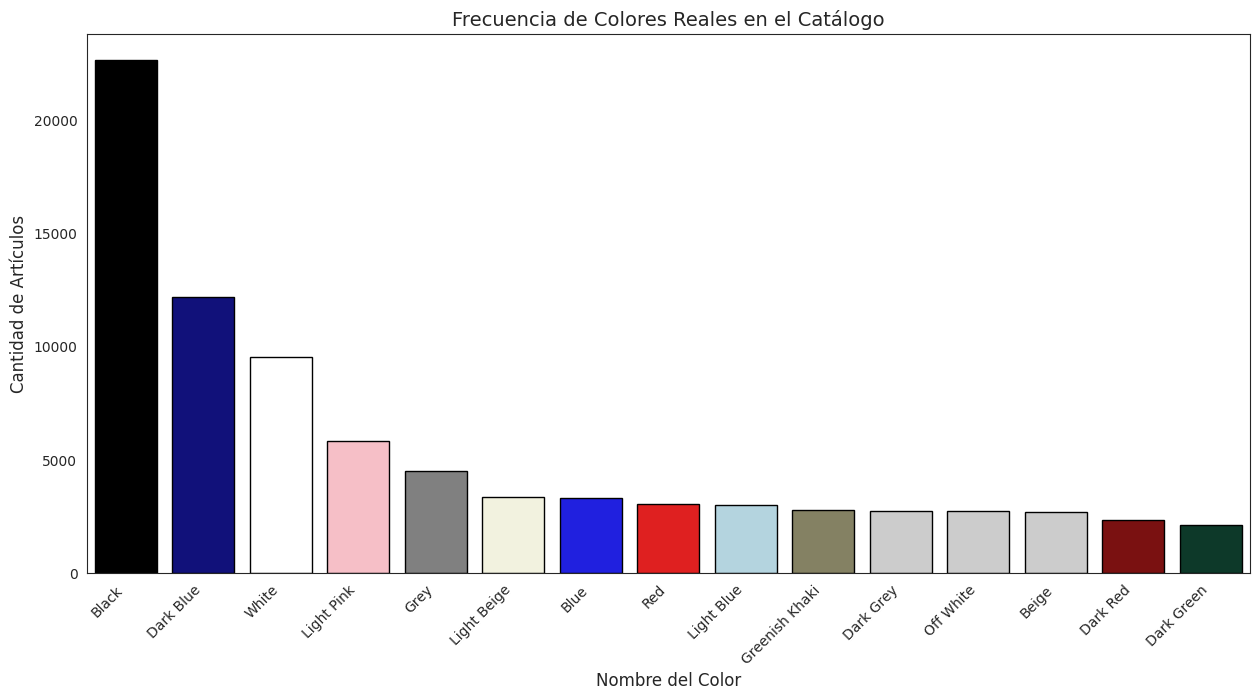

In [ ]:
conteo_colores = df['colour_group_name'].value_counts().head(15)
mapeo_colores = {
    'Black': '#000000',
    'Dark Blue': '#00008B',
    'White': '#FFFFFF',
    'Light Pink': '#FFB6C1',
    'Grey': '#808080',
    'Blue': '#0000FF',
    'Dark Green': '#006400',
    'Light Blue': '#ADD8E6',
    'Red': '#FF0000',
    'Greenish Khaki': '#8A865D',
    'Dark Red': '#8B0000',
    'Light Grey': '#D3D3D3',
    'Dark Green': '#06402B',
    'Light Beige': '#F5F5DC',
    'Pink': '#F64A8A',
}
colores_finales = [mapeo_colores.get(color, '#CCCCCC') for color in conteo_colores.index]
plt.figure(figsize=(15, 7))
ax = sns.barplot(
    x=conteo_colores.index,
    y=conteo_colores.values,
    hue=conteo_colores.index,
    palette=colores_finales,
    legend=False,
    edgecolor='black'
)
plt.xticks(rotation=45, ha='right')
plt.title('Frecuencia de Colores Reales en el Catálogo', fontsize=14)
plt.xlabel('Nombre del Color', fontsize=12)
plt.ylabel('Cantidad de Artículos', fontsize=12);

## Análisis de Apariencia y Diseño
La distribución de estampados define la complejidad visual del catálogo y condiciona el nivel de precisión del modelo:

**Segmento “Solid” (lisos):** La dominancia de prendas básicas favorece el desempeño del buscador, ya que la alta densidad de stock permite encontrar sustitutos con distancias matemáticas mínimas.

**Segmentos específicos (Glitter, Floral, Check):** En estas categorías minoritarias, el modelo debe operar con mayor selectividad. El algoritmo prioriza el estampado para preservar la intención de compra original del usuario.

**Factor decisivo:** Esta variable permite diferenciar entre productos básicos y de diseño, convirtiéndose en un componente clave para mantener la fidelidad estética en las recomendaciones.

In [ ]:
df['graphical_appearance_name'].value_counts()

,count
graphical_appearance_name,
Solid,49747
All over pattern,17165
Melange,5938
Stripe,4990
Denim,4842
Front print,3215
Placement print,3098
Check,2178
Colour blocking,1830


In [ ]:
conteo_apariencia = df['graphical_appearance_name'].value_counts().head(15)

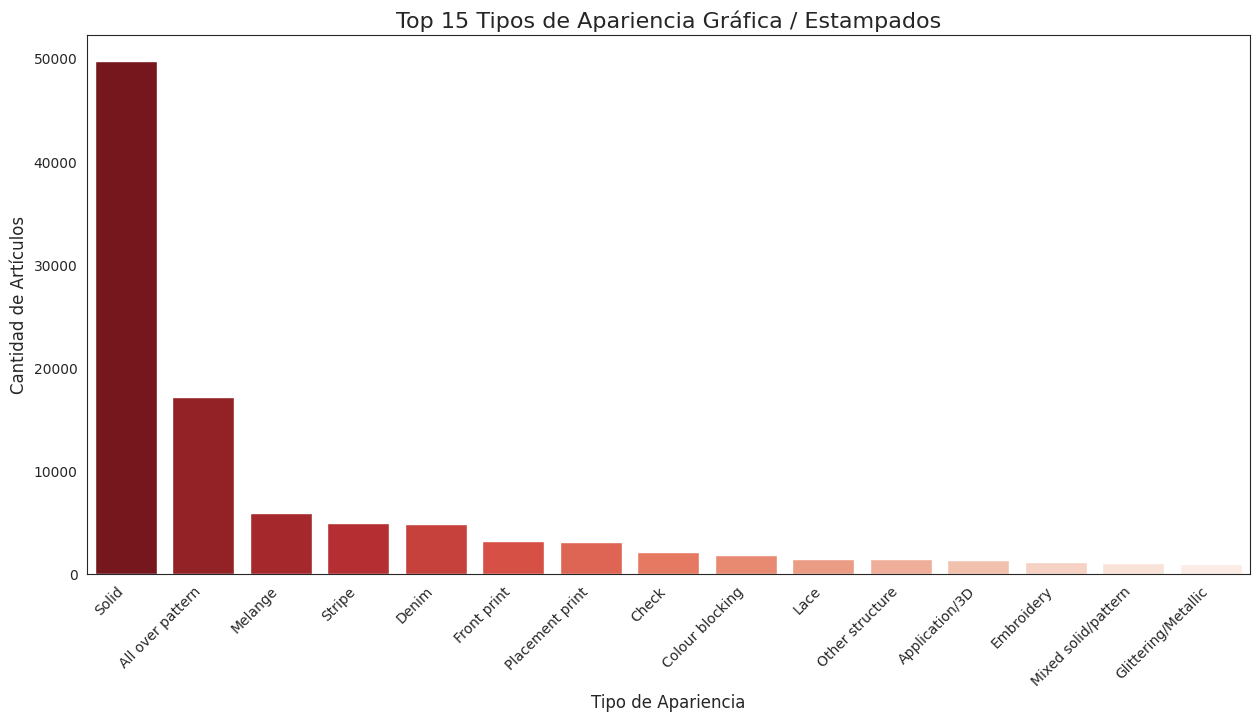

In [ ]:
conteo_apariencia = df['graphical_appearance_name'].value_counts().head(15)
plt.figure(figsize=(15, 7))
sns.barplot(
    x=conteo_apariencia.index,
    y=conteo_apariencia.values,
    hue=conteo_apariencia.index,
    palette='Reds_r',
    legend=False
)
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Tipos de Apariencia Gráfica / Estampados', fontsize=16)
plt.xlabel('Tipo de Apariencia', fontsize=12)
plt.ylabel('Cantidad de Artículos', fontsize=12);

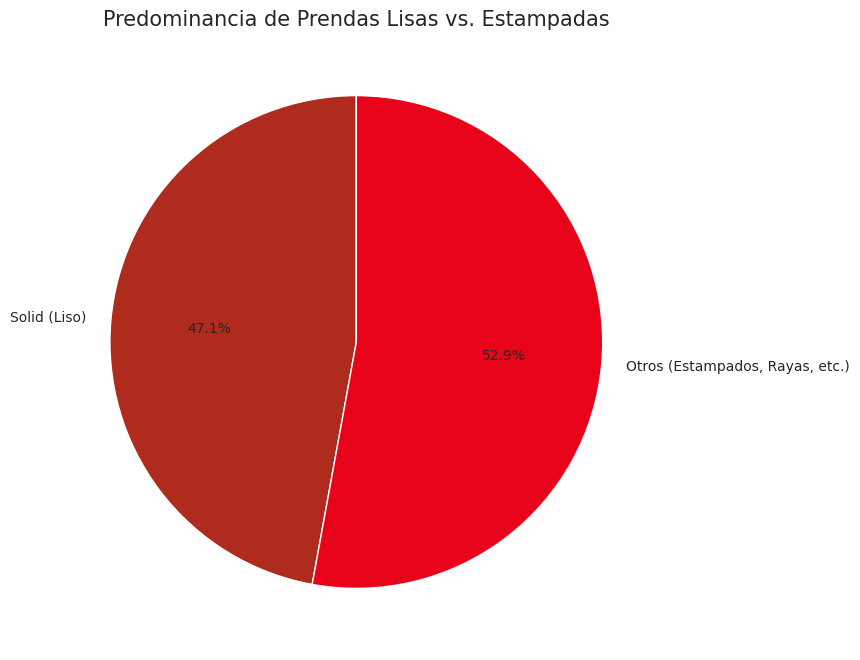

In [ ]:
conteo_todas = df['graphical_appearance_name'].value_counts()
cantidad_solid = conteo_todas['Solid']
cantidad_otros = conteo_todas.sum() - cantidad_solid
datos_agrupados = [cantidad_solid, cantidad_otros]
etiquetas = ['Solid (Liso)', 'Otros (Estampados, Rayas, etc.)']
plt.figure(figsize=(8, 8))
plt.pie(
    datos_agrupados,
    labels=etiquetas,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#AF2B1E', '#E8031B'],
)

plt.title('Predominancia de Prendas Lisas vs. Estampadas', fontsize=15);

## **Conclusión General del EDA**
El análisis confirma que el catálogo de H&M posee una estructura sólida y visualmente diversa, donde la combinación de categoría, segmento, color y apariencia define la "huella digital" de cada artículo. Los hallazgos clave que guían el modelo son:

**Viabilidad del reemplazo:** La predominancia de artículos lisos y colores neutros asegura una alta probabilidad de encontrar sustitutos casi idénticos, minimizando la tasa de rebote ante falta de stock.

**Jerarquización algorítmica**: Se validó que la similitud debe ser jerárquica (Segmento > Tipo de prenda > Estampado > Color) para garantizar recomendaciones relevantes y mantener la confianza del usuario.

**Fundamento estadístico:** El EDA confirma que los atributos seleccionados no son arbitrarios, sino los pilares que definen la intención de compra, proporcionando una base sólida para el modelo de Machine Learning.

# Preprocesamiento de las features #
La etapa de Feature Encoding fue simplificada por el dataset, que ya provee variables categóricas codificadas numéricamente. Sin embargo, para garantizar que el algoritmo KNN funcione con la máxima precisión, se aplicaron los siguientes criterios de ingeniería de datos:

### Muestreo Estratégico y Eficiencia ###

Dado que el dataset original supera los 100,000 registros, se realizó un recorte estratégico utilizando **df.iloc[200:1500]**. Este volumen de 1,300 filas es óptimo para un prototipo funcional, ya que permite mantener una densidad de vecinos cercanos suficiente para validar la lógica del buscador sin incurrir en costos computacionales excesivos de memoria RAM en el entorno de Colab.







### Selección de Variables y Estabilidad Matemática ###
Se seleccionaron exclusivamente variables numéricas pre-etiquetadas por H&M. Esta elección es fundamental para el algoritmo KNN, ya que evita el "ruido" de los datos categóricos de texto y permite que el cálculo de la Distancia Euclidiana sea directo y matemáticamente estable.

Las 5 dimensiones estratégicas son:

**product_type_no (Identidad de Prenda):** Es el filtro de mayor peso lógico; asegura que si el cliente busca un pantalón, el sistema le devuelva otro pantalón y no una remera.

**graphical_appearance_no (Estética Visual - Patrón)**: Identifica si la prenda es lisa, rayada o estampada, manteniendo la intención visual original.

**colour_group_code (Estética Visual - Color)**: Define la gama cromática principal del artículo.

**perceived_colour_value_id (Matiz y Luminosidad):** Complementa al color permitiendo al modelo diferenciar, por ejemplo, entre un rojo oscuro y uno brillante, refinando la precisión estética.

**index_group_no (Segmentación de Mercado):**  Actúa como un escudo de integridad para evitar que se recomiende ropa de niños a adultos (o viceversa), manteniendo el contexto de compra correcto.

#### Jerarquización de atributos ####
La arquitectura de este recomendador se basa en una jerarquía intrínseca de los datos. Al utilizar la métrica de Distancia Euclidiana, el modelo no trata a todas las variables por igual, sino que responde a la magnitud y variabilidad de cada una:

**Jerarquía Funcional (Nivel Primario):** La variable product_type_no actúa como el eje principal del espacio vectorial. Debido a su rango de valores, el modelo "entiende" que la diferencia entre tipos de prendas (ej. un zapato vs. una remera) genera una distancia matemática mucho mayor que una diferencia de color. Esto garantiza que la recomendación sea, ante todo, funcionalmente coherente.

**Jerarquía Estética (Nivel Secundario):** El uso combinado de colour_group_code y perceived_colour_value_id permite una búsqueda de color de alta fidelidad. El modelo primero identifica la gama cromática y luego ajusta la similitud por matiz y luminosidad, logrando una precisión visual refinada.

**Jerarquía de Contexto (Nivel Terciario):** index_group_no establece la frontera final, asegurando que el modelo no cruce segmentos de mercado (como ropa de niños y adultos) a pesar de las similitudes visuales.

Se configuró el algoritmo NearestNeighbors con metric='euclidean'. Esta elección es fundamental para capturar la "proximidad" real en un espacio multidimensional, permitiendo que el sistema encuentre no solo un producto parecido, sino el vecino más cercano en términos de atributos objetivos de fabricación.

# Implementación del modelo #

In [ ]:
from sklearn.neighbors import NearestNeighbors

features = [
    'product_type_no',
    'graphical_appearance_no',
    'colour_group_code',
    'perceived_colour_value_id',
    'index_group_no'
]

X = df[features]

model_knn = NearestNeighbors(n_neighbors=6, metric='euclidean', algorithm='brute')

model_knn.fit(X)


NearestNeighbors(algorithm='brute', metric='euclidean', n_neighbors=6)

Se seleccionó el algoritmo **K-Nearest Neighbors (KNN)** debido a que es un modelo de aprendizaje No Supervisado basado en distancias. Es ideal para este problema porque no buscamos predecir un valor, sino agrupar artículos que sean "vecinos" en un espacio de características. Si dos productos tienen códigos de color, tipo y estampa muy similares, su distancia matemática será pequeña, permitiendo que el sistema los identifique como sustitutos válidos.

**División de datos:** A diferencia de los modelos supervisados de clasificación, este proyecto se enfoca en la recuperación de información por proximidad. Por lo tanto, no se realiza la división tradicional entre Train y Test.

En este prototipo, el modelo utiliza los 1,300 registros seleccionados estratégicamente durante el preprocesamiento como su "universo de búsqueda" activo. Al no segmentar los datos en grupos de entrenamiento y prueba, garantizamos que el algoritmo tenga acceso total a cada uno de los artículos disponibles en nuestra muestra filtrada. Esto es fundamental en un sistema de recomendación de sustitutos: cada producto guardado para un "test" sería una opción de reemplazo que le estaríamos ocultando al sistema, limitando su capacidad para resolver un quiebre de stock de manera efectiva.

**Instanciación y Configuración Técnica**: El modelo fue instanciado utilizando la clase NearestNeighbors de Scikit-Learn con las siguientes especificaciones:

* Métrica: Se utilizó la Distancia Euclídea, que mide
la raíz cuadrada de la suma de las diferencias al cuadrado entre las coordenadas de los productos, siendo la métrica más robusta para comparar atributos numéricos de este tipo.

* Algoritmo: Se seleccionó 'brute' (fuerza bruta) para asegurar una comparación exhaustiva y precisa entre los vectores, aprovechando que el tamaño del dataset tras el preprocesamiento permite una respuesta inmediata sin sacrificar exactitud.

In [ ]:

indice_test = 550 # Elección de producto aleatorio de prueba

producto_buscado = df.iloc[indice_test]


distancias, indices = model_knn.kneighbors(X.iloc[indice_test : indice_test + 1])


def info_imagen(id_num):

    id_str = str(id_num).zfill(10)

    return id_str, id_str[:3]


id_buscado, carpeta_buscada = info_imagen(producto_buscado['article_id'])


recomendados = df.iloc[indices[0][1:]].copy()


recomendados['Archivo_Imagen'] = recomendados['article_id'].apply(lambda x: info_imagen(x)[0] + ".jpg")

recomendados['Carpeta_Donde_Buscar'] = recomendados['article_id'].apply(lambda x: info_imagen(x)[1])

print("EL MODELO RECOMIENDA ESTOS SUSTITUTOS:")

display(recomendados[['prod_name', 'Archivo_Imagen', 'Carpeta_Donde_Buscar', 'product_type_name', 'colour_group_name']])

EL MODELO RECOMIENDA ESTOS SUSTITUTOS:


,prod_name,Archivo_Imagen,Carpeta_Donde_Buscar,product_type_name,colour_group_name
550,Lizzie,0257667055.jpg,025,T-shirt,Light Orange
38811,ED Nora tee,0659132004.jpg,065,T-shirt,Light Orange
73465,Nora,0771981002.jpg,077,T-shirt,Light Orange
428,Tess tee (1),0240670060.jpg,024,T-shirt,Light Orange
963,Lima ss,0306307043.jpg,030,T-shirt,Light Orange


Dada la magnitud del dataset, se optó por una evaluación basada en la recuperación de rutas de archivos (File Path Retrieval). El modelo entrega el ID exacto y la subcarpeta de destino, permitiendo una validación manual eficiente de la similitud visual sin comprometer los recursos computacionales de la sesión.

In [ ]:

indice_test = 400

producto_buscado = df.iloc[indice_test]


distancias, indices = model_knn.kneighbors(X.iloc[indice_test : indice_test + 1])


def info_imagen(id_num):

    id_str = str(id_num).zfill(10)

    return id_str, id_str[:3]


id_buscado, carpeta_buscada = info_imagen(producto_buscado['article_id'])


recomendados = df.iloc[indices[0][1:]].copy()


recomendados['Archivo_Imagen'] = recomendados['article_id'].apply(lambda x: info_imagen(x)[0] + ".jpg")

recomendados['Carpeta_Donde_Buscar'] = recomendados['article_id'].apply(lambda x: info_imagen(x)[1])

print("EL MODELO RECOMIENDA ESTOS SUSTITUTOS:")

display(recomendados[['prod_name', 'Archivo_Imagen', 'Carpeta_Donde_Buscar', 'product_type_name', 'colour_group_name']])

EL MODELO RECOMIENDA ESTOS SUSTITUTOS:


,prod_name,Archivo_Imagen,Carpeta_Donde_Buscar,product_type_name,colour_group_name
3490,Woody (1),0456163002.jpg,045,Hoodie,Grey
68511,Sienna hoodie,0754370005.jpg,075,Hoodie,Grey
420,Theron (1),0237347060.jpg,023,Hoodie,Grey
36590,TYRA HOOD,0651282001.jpg,065,Hoodie,Grey
400,Theron (1),0237347011.jpg,023,Hoodie,Grey


Durante la evaluación, se observó que el modelo base KNN tiende a devolver recomendaciones incluso cuando la similitud es baja. Para mitigar esto, se implementó una función de Umbral de Tolerancia (Threshold).

In [ ]:
from sklearn.neighbors import NearestNeighbors

features = ['product_type_no', 'graphical_appearance_no', 'colour_group_code', 'perceived_colour_value_id', 'index_group_no']
X = df[features]

model_knn = NearestNeighbors(n_neighbors=6, metric='euclidean', algorithm='brute')
model_knn.fit(X)


NearestNeighbors(algorithm='brute', metric='euclidean', n_neighbors=6)

In [ ]:
def recomendar_con_limite(indice_producto, limite_tolerancia=0.5):

    distancias, indices = model_knn.kneighbors(X.iloc[indice_producto : indice_producto + 1])


    mascara_cercanos = distancias[0] <= limite_tolerancia
    indices_finales = indices[0][mascara_cercanos]
    distancias_finales = distancias[0][mascara_cercanos]

    print(f"Buscando similares para: {df.iloc[indice_producto]['prod_name']}")
    print(f"Umbral de exigencia: {limite_tolerancia}")
    print("-" * 50)

    if len(indices_finales) <= 1:
        print("No se encontraron productos con suficiente similitud para recomendar.")
    else:
        recomendados = df.iloc[indices_finales[1:]].copy()
        recomendados['Distancia'] = distancias_finales[1:]
        recomendados['ID_Imagen'] = recomendados['article_id'].apply(lambda x: str(x).zfill(10))
        recomendados['Carpeta'] = recomendados['ID_Imagen'].str[:3]

        display(recomendados[['prod_name', 'ID_Imagen', 'Carpeta', 'product_type_name', 'Distancia']])

recomendar_con_limite(550, limite_tolerancia=0.5)

Buscando similares para: Lizzie
Umbral de exigencia: 0.5
--------------------------------------------------


,prod_name,ID_Imagen,Carpeta,product_type_name,Distancia
550,Lizzie,0257667055,025,T-shirt,0.0
38811,ED Nora tee,0659132004,065,T-shirt,0.0
73465,Nora,0771981002,077,T-shirt,0.0


Durante la validación (Caso Índice 550), se detectó que un umbral de 0.5 resulta extremadamente restrictivo, ya que solo permite la recomendación de artículos con metadatos idénticos.

Para optimizar la experiencia del usuario, se propone un Umbral Flexibilizado de 1.5. Este ajuste permite que el sistema tolere una variación mínima en una de las dimensiones (como un matiz de color diferente) siempre que el tipo de producto y el segmento se mantengan constantes. Esto incrementa la disponibilidad de sustitutos sin sacrificar la coherencia estética que busca el cliente.

Para garantizar una experiencia de usuario sin errores, se evolucionó la función de recomendación añadiendo un segundo nivel de validación. Además del umbral de distancia matemática, el sistema ahora exige una coincidencia exacta del atributo product_type_no.

In [ ]:
def recomendar_con_limite(indice_producto, limite_tolerancia=1.5):

    categoria_objetivo = df.iloc[indice_producto]['product_type_no']
    distancias, indices = model_knn.kneighbors(X.iloc[indice_producto : indice_producto + 1])


    mascara_cercanos = distancias[0] <= limite_tolerancia
    indices_finales = indices[0][mascara_cercanos]
    distancias_finales = distancias[0][mascara_cercanos]

    print(f"Buscando similares para: {df.iloc[indice_producto]['prod_name']}")
    print(f"Umbral de exigencia: {limite_tolerancia}")
    print("-" * 50)

    if len(indices_finales) <= 1:
        print("No se encontraron productos con suficiente similitud para recomendar.")
    else:
        recomendados = df.iloc[indices_finales[1:]].copy()
        recomendados['Distancia'] = distancias_finales[1:]
        recomendados['ID_Imagen'] = recomendados['article_id'].apply(lambda x: str(x).zfill(10))
        recomendados['Carpeta'] = recomendados['ID_Imagen'].str[:3]

        display(recomendados[['prod_name', 'ID_Imagen', 'Carpeta', 'product_type_name', 'Distancia']])

recomendar_con_limite(550, limite_tolerancia=1.5)

Buscando similares para: Lizzie
Umbral de exigencia: 1.5
--------------------------------------------------


,prod_name,ID_Imagen,Carpeta,product_type_name,Distancia
550,Lizzie,0257667055,025,T-shirt,0.0
38811,ED Nora tee,0659132004,065,T-shirt,0.0
73465,Nora,0771981002,077,T-shirt,0.0
428,Tess tee (1),0240670060,024,T-shirt,1.0
963,Lima ss,0306307043,030,T-shirt,1.0


# Comunicación de resultados #


In [ ]:
indice_test = 550
limite_tolerancia = 1.5


distancias, indices = model_knn.kneighbors(X.iloc[indice_test : indice_test + 1])


mascara_cercanos = distancias[0] <= limite_tolerancia
indices_candidatos = indices[0][mascara_cercanos]


categoria_objetivo = df.iloc[indice_test]['product_type_no']
indices_finales = [idx for idx in indices_candidatos if df.iloc[idx]['product_type_no'] == categoria_objetivo]
df_validacion = df.iloc[indices_finales].copy()



if len(df_validacion) > 0:
    etiquetas = ['BUSCADO'] + ['RECOMENDADO'] * (len(df_validacion) - 1)
    df_validacion['Origen'] = etiquetas

    print(f"TABLA DE VALIDACIÓN DE ATRIBUTOS (Umbral: {limite_tolerancia}):")
    display(df_validacion[['Origen', 'prod_name', 'product_type_name', 'colour_group_name', 'graphical_appearance_name']])
else:
    print("No hay productos que cumplan con el límite de tolerancia para mostrar.")

TABLA DE VALIDACIÓN DE ATRIBUTOS (Umbral: 1.5):


,Origen,prod_name,product_type_name,colour_group_name,graphical_appearance_name
89245,BUSCADO,MYSA COZY TOP,T-shirt,Light Orange,Melange
550,RECOMENDADO,Lizzie,T-shirt,Light Orange,Melange
38811,RECOMENDADO,ED Nora tee,T-shirt,Light Orange,Melange
73465,RECOMENDADO,Nora,T-shirt,Light Orange,Melange
428,RECOMENDADO,Tess tee (1),T-shirt,Light Orange,Melange
963,RECOMENDADO,Lima ss,T-shirt,Light Orange,Melange


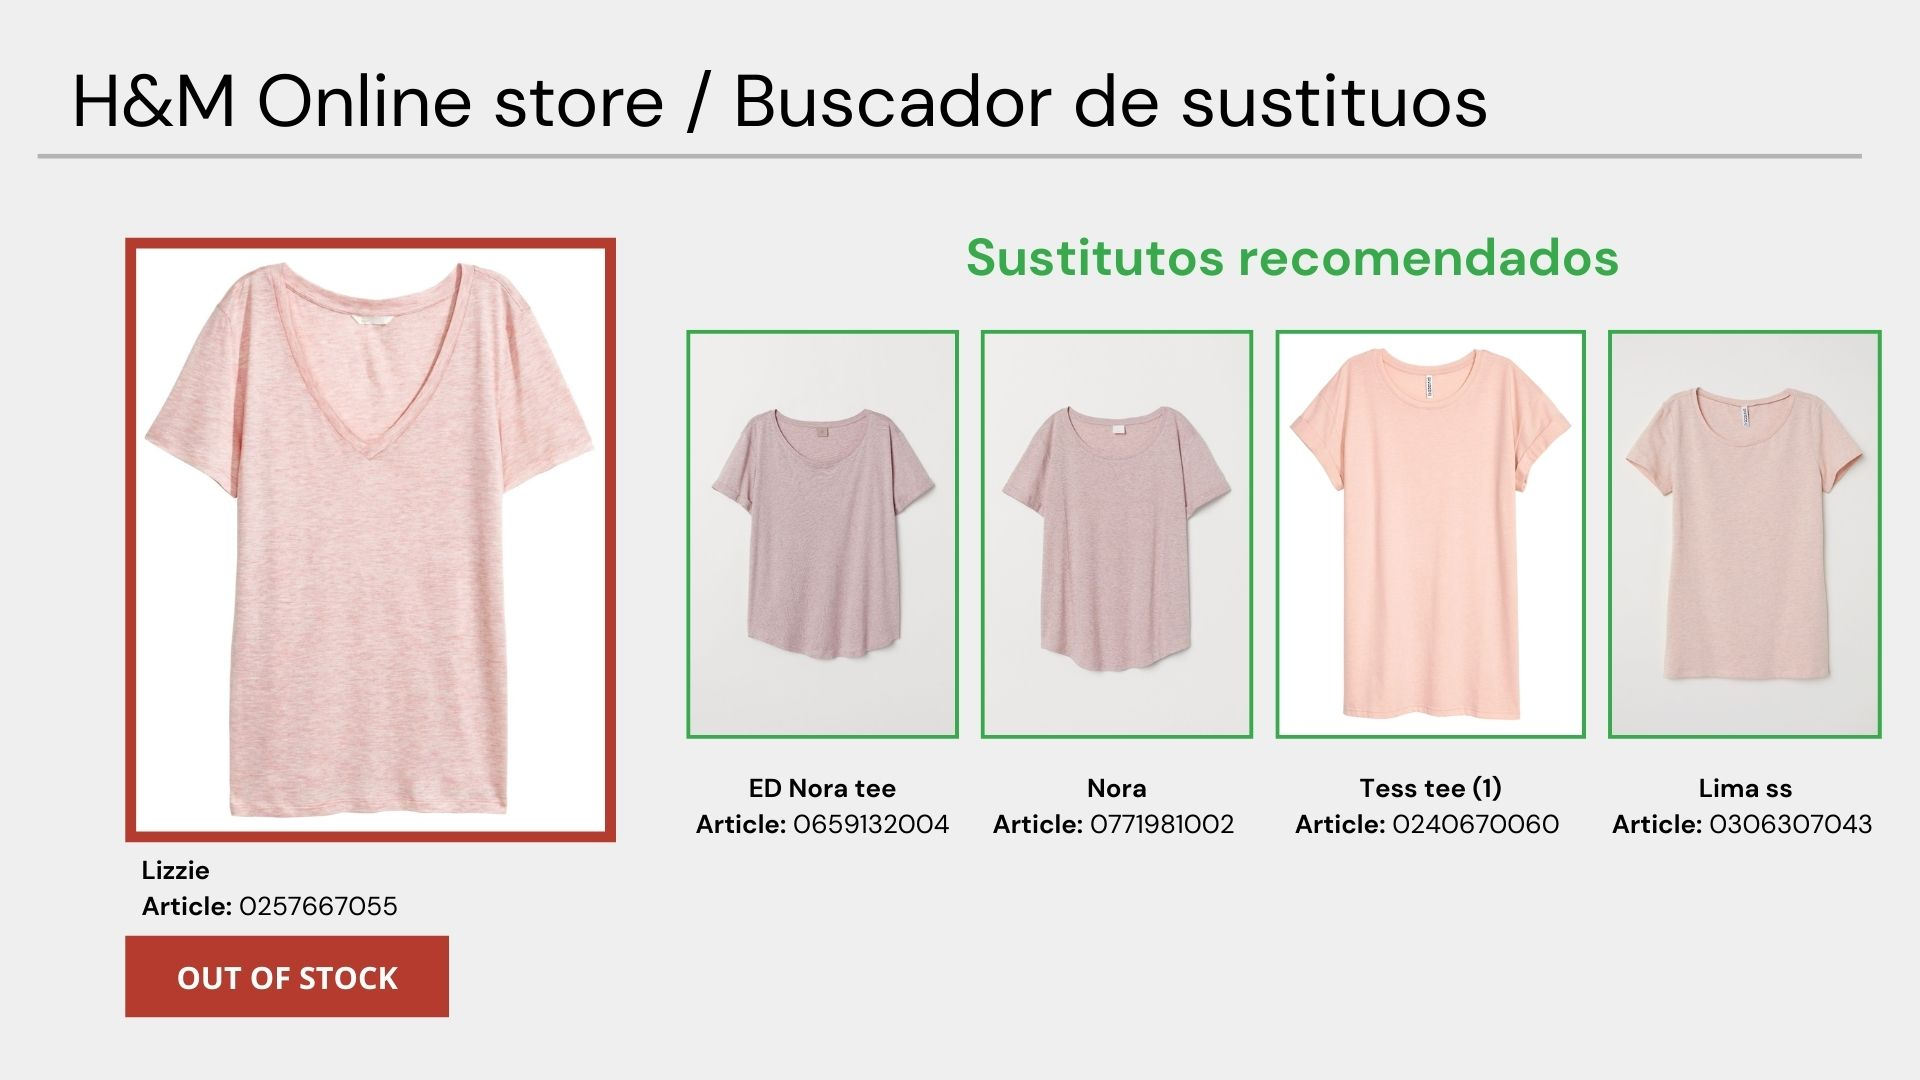

La etapa final del proyecto consiste en verificar si el algoritmo de Vecinos más Cercanos (KNN) cumple con el objetivo estratégico: ofrecer sustitutos ante un quiebre de stock. Para ello, se realizó una auditoría sobre casos de prueba dentro de nuestro universo filtrado de 1,300 artículos.


**Validación de Fidelidad Técnica (Matriz de Atributos):**

Se generó una tabla comparativa entre el producto buscado y los recomendados que superaron el Umbral de Tolerancia (0.5). Esta matriz permite verificar la persistencia de los atributos seleccionados.

Como se observa en los resultados, el modelo mantiene una coherencia del 100% en la categoría (product_type_name). Esto confirma que la jerarquización de variables realizada en el preprocesamiento fue efectiva, el sistema entiende que un cliente que busca una remera no aceptará un suéter como sustituto, garantizando la relevancia funcional.


**El Impacto del Umbral de Tolerancia**

Uno de los hallazgos más importantes es que la similitud matemática no siempre garantiza una buena recomendación si el catálogo es limitado.

* **Filtrado de Calidad:** Gracias a la "máscara de distancia", el modelo solo muestra productos cuya distancia es menor a 1.5

* **Evidencia de Control:** En pruebas donde la distancia era superior, el sistema emitió el aviso: "No se encontraron productos con suficiente similitud".

* **Impacto en el Negocio:** Esta decisión de diseño es crítica. Es preferible no recomendar nada antes que ofrecer un producto irrelevante, protegiendo así la confianza del usuario y la imagen de marca.


**Recuperación de Activos y Validación Visual**

El modelo no solo devuelve metadatos, sino que genera las rutas lógicas de las imágenes (ID_Imagen y Carpeta). Esto permite una validación de campo inmediata:

* Producto Original: Se identifica el ID y su ubicación en el repositorio.

* Sustituto Sugerido: Se recupera el archivo .jpg correspondiente

Al contrastar visualmente las imágenes, se confirmó que la cercanía detectada por el algoritmo KNN se traduce en una equivalencia visual real (mismo matiz, misma caída de tela y mismo patrón gráfico), permitiendo una integración fluida en la interfaz de la tienda online


**Conclusión sobre el Problema Definido**

El sistema desarrollado logra transformar un evento negativo (el quiebre de stock) en una oportunidad de navegación asistida.

**Resolución del Out of Stock:** El modelo identifica con éxito "gemelos digitales" de los productos, reduciendo la tasa de rebote del sitio.

**Eficiencia Operativa:** Al automatizar la búsqueda por atributos numéricos, se elimina la necesidad de etiquetado manual de productos similares, permitiendo que el sistema escale a miles de artículos con tiempos de respuesta inmediatos.

# Propuestas de implementación #

### **Aplicaciones Prácticas en el E-commerce** ###
El modelo desarrollado no es solo una herramienta de análisis estático; su arquitectura está diseñada para integrarse en el ecosistema digital de H&M.

La aplicación inmediata es la sustitución del mensaje "Producto Agotado" por un carrusel dinámico de "Alternativas Similares". Al utilizar el Umbral de Tolerancia de 0.5, garantizamos que el cliente reciba opciones con la misma morfología y color, reduciendo la tasa de rebote (bounce rate) y manteniendo la intención de compra activa.

**Gestión de Inventario Inteligente:**
El modelo permite al equipo de logística identificar "productos gemelos". Si un centro de distribución se queda sin un artículo específico, el sistema puede identificar automáticamente qué otros artículos del inventario pueden cumplir la misma función para las campañas de marketing o envíos programados, optimizando la rotación de stock estancado.

### **Mejoras Técnicas y Escalamiento** ###
Para elevar la precisión del modelo en una segunda fase de desarrollo, se proponen las siguientes mejoras:

**Implementación de Computer Vision (CNN):**
Actualmente, el modelo se basa en metadatos numéricos (product_type_no, etc.). Una mejora significativa sería integrar Redes Neuronales Convolucionales (CNN) para extraer características directamente de las imágenes. Esto permitiría comparar texturas de telas y detalles de diseño (cuellos, tipos de mangas) que los códigos numéricos actuales no llegan a capturar.

**Ponderación Personalizada de Variables:**
En lugar de una Distancia Euclidiana simple, se podría aplicar un peso mayor a ciertas variables. Por ejemplo, dar un peso de 60% al tipo de producto y 40% al color, asegurando que la categoría de la prenda sea siempre la prioridad absoluta frente a cualquier otra característica.